# Nguyễn Văn Ước — 2A202602445
VinUni AI20K — Track 4. Topic A: LiDAR-camera calibration QA.

Chọn runtime **CPU** rồi **Run all**. Notebook chạy 100 frame × 9 mức yaw, không dùng GPU/model. Dữ liệu lấy từ repo đề (~135 MB). Các file triển khai đính kèm trong notebook; không cần push code trước. Cuối notebook tải results/report/source về máy, ghép vào repo rồi nộp LMS.

Notebook do Codex hỗ trợ; cần tự đọc code, chạy và đối chiếu ảnh/số liệu trước nộp.

In [2]:
from pathlib import Path
import subprocess, sys, os, json, hashlib
workspace = Path("/content/ai20k_day6_uoc")
if not workspace.exists():
    subprocess.run(["git", "clone", "--depth", "1", "https://github.com/VinUni-AI20k/K4-Track4-Day06-3D-From-Point-Clouds.git", str(workspace)], check=True)
os.chdir(workspace)
subprocess.run([sys.executable, "-m", "pip", "install", "-r", "requirements.txt"], check=True)
print("Repo:", workspace)

Repo: /content/ai20k_day6_uoc


## Các file triển khai
Cell này ghi projection, script benchmark, kiểm thử và script sinh báo cáo. Chỉ hai hàm TODO trong projection khác starter đề bài.

In [3]:
implementation = {
  "starter/projection.py": "\"\"\"LiDAR -> camera projection, overlay và perturb calibration.\n\nHai hàm có `TODO(CP2)` là phần học viên phải tự cài đặt (bắt buộc cho topic A, C, F;\nkhuyến khích cho mọi topic vì đây là bài test calibration rẻ nhất).\n\nChạy thử sau khi cài đặt xong (cùng một code chạy được cho cả KITTI và nuScenes):\n    python -m starter.projection --data-root data/synthetic --frame 000000\n    python -m starter.projection --data-root data/synthetic --frame 000000 --yaw-deg 1.0\n    python -m starter.projection --data-root data/kitti_mini --frame 000011\n    python -m starter.projection --data-root data/nuscenes_mini_subset --frame scene-0103_010\n    python -m starter.projection --data-root data/nuscenes_mini_subset --frame scene-0103_010 --ignore-ego-motion\n\"\"\"\nfrom __future__ import annotations\n\nimport argparse\nimport copy\nfrom pathlib import Path\n\nimport cv2\nimport numpy as np\n\nfrom starter.datasets import dataset_type, load_frame\nfrom starter.kitti_io import KittiCalib, KittiObject\n\n\ndef velo_to_cam(points_xyz: np.ndarray, calib: KittiCalib) -> np.ndarray:\n    \"\"\"Đưa điểm (N, 3) từ velodyne frame sang rectified camera frame (N, 3).\n\n    TODO(CP2):\n      1. Chuyển sang toạ độ đồng nhất (N, 4).\n      2. Nhân với calib.T_cam_velo (4x4). Chú ý chiều nhân và transpose.\n      3. Trả về 3 cột đầu.\n    Tự kiểm: một điểm velodyne (10, 0, 0) phải có z_cam ~ 10 (phía trước camera).\n    \"\"\"\n    points_xyz = np.asarray(points_xyz, dtype=np.float64)\n    if points_xyz.ndim != 2 or points_xyz.shape[1] != 3:\n        raise ValueError(\"points_xyz must have shape (N, 3)\")\n    homogeneous = np.column_stack((points_xyz, np.ones(len(points_xyz))))\n    with np.errstate(invalid=\"ignore\"):\n        return (homogeneous @ calib.T_cam_velo.T)[:, :3]\n\n\ndef cam_to_image(points_cam: np.ndarray, P2: np.ndarray, image_shape: tuple[int, ...],\n                 min_depth: float = 0.1) -> tuple[np.ndarray, np.ndarray, np.ndarray]:\n    \"\"\"Chiếu điểm camera frame (N, 3) lên ảnh bằng P2 (3x4).\n\n    Trả về:\n      uv    (M, 2) toạ độ pixel của các điểm hợp lệ\n      depth (M,)   z_cam của các điểm hợp lệ\n      mask  (N,)   bool, True nếu điểm hợp lệ\n\n    Điểm hợp lệ = depth > min_depth VÀ nằm trong ảnh (0 <= u < W, 0 <= v < H).\n\n    TODO(CP2):\n      1. Lọc điểm không hợp lệ (NaN/Inf): dữ liệu thật không bao giờ sạch.\n      2. Toạ độ đồng nhất, nhân P2 -> (N, 3) = [s*u, s*v, s].\n      3. Chia cho s để có (u, v). Chỉ chia với điểm có depth > min_depth.\n      4. Lọc theo kích thước ảnh image_shape[:2] = (H, W).\n    \"\"\"\n    points_cam = np.asarray(points_cam, dtype=np.float64)\n    if points_cam.ndim != 2 or points_cam.shape[1] != 3:\n        raise ValueError(\"points_cam must have shape (N, 3)\")\n    h, w = image_shape[:2]\n    mask = np.isfinite(points_cam).all(axis=1) & (points_cam[:, 2] > min_depth)\n    indices = np.flatnonzero(mask)\n    homogeneous = np.column_stack((points_cam[indices], np.ones(len(indices))))\n    projected = homogeneous @ np.asarray(P2).T\n    valid_scale = np.isfinite(projected).all(axis=1) & (projected[:, 2] > 1e-12)\n    uv = np.full((len(indices), 2), np.nan)\n    uv[valid_scale] = projected[valid_scale, :2] / projected[valid_scale, 2:3]\n    inside = valid_scale & (uv[:, 0] >= 0) & (uv[:, 0] < w) & (uv[:, 1] >= 0) & (uv[:, 1] < h)\n    mask[:] = False\n    mask[indices[inside]] = True\n    return uv[inside], points_cam[mask, 2], mask\n\n\ndef project_velo_to_image(points: np.ndarray, calib: KittiCalib, image_shape: tuple[int, ...]):\n    \"\"\"points (N, >=3) velodyne -> (uv, depth, mask) như `cam_to_image`.\"\"\"\n    return cam_to_image(velo_to_cam(points[:, :3], calib), calib.P2, image_shape)\n\n\ndef overlay_points(image: np.ndarray, uv: np.ndarray, depth: np.ndarray,\n                   max_depth: float = 50.0, radius: int = 2) -> np.ndarray:\n    \"\"\"Vẽ điểm lên ảnh, màu theo depth (gần = đỏ, xa = xanh).\"\"\"\n    out = image.copy()\n    d = np.clip(depth / max_depth, 0, 1)\n    colors = cv2.applyColorMap((255 * (1 - d)).astype(np.uint8).reshape(-1, 1), cv2.COLORMAP_JET)\n    for (u, v), c in zip(uv.astype(int), colors[:, 0]):\n        cv2.circle(out, (int(u), int(v)), radius, tuple(int(x) for x in c), -1)\n    return out\n\n\ndef _rot(roll: float, pitch: float, yaw: float) -> np.ndarray:\n    cr, sr, cp, sp, cy, sy = np.cos(roll), np.sin(roll), np.cos(pitch), np.sin(pitch), np.cos(yaw), np.sin(yaw)\n    Rx = np.array([[1, 0, 0], [0, cr, -sr], [0, sr, cr]])\n    Ry = np.array([[cp, 0, sp], [0, 1, 0], [-sp, 0, cp]])\n    Rz = np.array([[cy, -sy, 0], [sy, cy, 0], [0, 0, 1]])\n    return Rz @ Ry @ Rx\n\n\ndef perturb_extrinsic(calib: KittiCalib, roll_deg: float = 0.0, pitch_deg: float = 0.0,\n                      yaw_deg: float = 0.0, t_xyz_m: tuple[float, float, float] = (0, 0, 0)) -> KittiCalib:\n    \"\"\"Giả lập calibration drift: xoay/dịch LiDAR trong chính velodyne frame\n    (yaw quanh z-up, pitch quanh y-left, roll quanh x-forward) rồi ghép vào Tr_velo_to_cam.\"\"\"\n    D = np.eye(4)\n    D[:3, :3] = _rot(*np.deg2rad([roll_deg, pitch_deg, yaw_deg]))\n    D[:3, 3] = t_xyz_m\n    Tr = np.eye(4)\n    Tr[:3, :] = calib.Tr_velo_to_cam\n    out = copy.deepcopy(calib)\n    out.Tr_velo_to_cam = (Tr @ D)[:3, :]\n    return out\n\n\ndef box3d_corners_cam(obj: KittiObject) -> np.ndarray:\n    \"\"\"8 góc (8, 3) của box KITTI trong rectified camera frame.\n    Thứ tự: 4 góc đáy (y=0) rồi 4 góc nóc (y=-h).\"\"\"\n    h, w, l = obj.dimensions\n    x = np.array([l, l, -l, -l, l, l, -l, -l]) / 2\n    y = np.array([0, 0, 0, 0, -h, -h, -h, -h])\n    z = np.array([w, -w, -w, w, w, -w, -w, w]) / 2\n    c, s = np.cos(obj.rotation_y), np.sin(obj.rotation_y)\n    R = np.array([[c, 0, s], [0, 1, 0], [-s, 0, c]])\n    return (R @ np.vstack([x, y, z])).T + obj.location\n\n\ndef draw_box2d(image: np.ndarray, bbox, color=(0, 255, 0), label: str | None = None) -> np.ndarray:\n    out = image.copy()\n    x1, y1, x2, y2 = (int(round(v)) for v in bbox)\n    cv2.rectangle(out, (x1, y1), (x2, y2), color, 2)\n    if label:\n        cv2.putText(out, label, (x1, max(0, y1 - 5)), cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 1)\n    return out\n\n\ndef main() -> None:\n    ap = argparse.ArgumentParser(description=\"Chiếu điểm LiDAR lên ảnh camera, tô màu theo độ sâu, vẽ 2D box của label\")\n    ap.add_argument(\"--data-root\", default=\"data/synthetic\",\n                    help=\"thư mục KITTI (data/synthetic, data/kitti_mini) hoặc nuScenes (data/nuscenes_mini_subset)\")\n    ap.add_argument(\"--frame\", default=\"000000\", help=\"KITTI: 000011. nuScenes: scene-0103_010\")\n    ap.add_argument(\"--out-dir\", default=\"results/figures\", help=\"nơi lưu ảnh overlay\")\n    ap.add_argument(\"--roll-deg\", type=float, default=0.0, help=\"giả lập LiDAR bị xoay quanh trục x (độ)\")\n    ap.add_argument(\"--pitch-deg\", type=float, default=0.0, help=\"giả lập LiDAR bị xoay quanh trục y (độ)\")\n    ap.add_argument(\"--yaw-deg\", type=float, default=0.0, help=\"giả lập LiDAR bị xoay quanh trục z hướng lên (độ)\")\n    ap.add_argument(\"--tx\", type=float, default=0.0, help=\"giả lập LiDAR bị dịch theo trục x của LiDAR (mét)\")\n    ap.add_argument(\"--ty\", type=float, default=0.0, help=\"giả lập LiDAR bị dịch theo trục y của LiDAR (mét)\")\n    ap.add_argument(\"--tz\", type=float, default=0.0, help=\"giả lập LiDAR bị dịch theo trục z của LiDAR (mét)\")\n    ap.add_argument(\"--ignore-ego-motion\", action=\"store_true\",\n                    help=\"chỉ cho nuScenes: bỏ bù chuyển động xe giữa thời điểm chụp LiDAR và camera\")\n    args = ap.parse_args()\n\n    kwargs = {\"use_ego_motion\": not args.ignore_ego_motion} if dataset_type(args.data_root) == \"nuscenes\" else {}\n    fr = load_frame(args.data_root, args.frame, **kwargs)\n    calib = perturb_extrinsic(fr[\"calib\"], args.roll_deg, args.pitch_deg, args.yaw_deg,\n                              (args.tx, args.ty, args.tz))\n    uv, depth, mask = project_velo_to_image(fr[\"points\"], calib, fr[\"image\"].shape)\n    vis = overlay_points(fr[\"image\"], uv, depth)\n    for obj in fr[\"labels\"]:\n        vis = draw_box2d(vis, obj.bbox, label=obj.type)\n\n    tag = f\"r{args.roll_deg}_p{args.pitch_deg}_y{args.yaw_deg}_t{args.tx}_{args.ty}_{args.tz}\"\n    if args.ignore_ego_motion:\n        tag += \"_noego\"\n    out = Path(args.out_dir) / f\"overlay_{args.frame}_{tag}.png\"\n    out.parent.mkdir(parents=True, exist_ok=True)\n    cv2.imwrite(str(out), vis)\n    print(f\"points={len(mask)} inside_image={int(mask.sum())} ({mask.mean():.1%}) -> {out}\")\n\n\nif __name__ == \"__main__\":\n    main()\n",
  "src/calibration_qa.py": "\"\"\"Topic A — original experiment prepared with Codex; see report AI disclosure.\nGeometry conventions and data readers: starter/kitti_io.py and data/README.md.\nNo detector, no training, no external dataset downloads.\n\"\"\"\nfrom __future__ import annotations\nimport argparse\nimport json\nfrom pathlib import Path\nimport numpy as np\nimport pandas as pd\nimport cv2\nimport matplotlib\nmatplotlib.use('Agg')\nimport matplotlib.pyplot as plt\nfrom starter.datasets import list_frames, load_frame\nfrom starter.projection import velo_to_cam, cam_to_image, perturb_extrinsic, overlay_points, draw_box2d\n\n\ndef object_membership(camera_points, obj):\n    \"\"\"Inverse KITTI yaw; location is bottom centre. Keep GT membership fixed.\"\"\"\n    c, s = np.cos(obj.rotation_y), np.sin(obj.rotation_y)\n    rotation = np.array([[c, 0, s], [0, 1, 0], [-s, 0, c]])\n    local = (camera_points - obj.location) @ rotation\n    h, w, l = obj.dimensions\n    return (np.isfinite(local).all(axis=1) & (np.abs(local[:, 0]) <= l/2)\n            & (local[:, 1] >= -h) & (local[:, 1] <= 0)\n            & (np.abs(local[:, 2]) <= w/2))\n\n\ndef in_box(uv, bbox):\n    x1, y1, x2, y2 = bbox\n    return ((uv[:, 0] >= x1) & (uv[:, 0] <= x2)\n            & (uv[:, 1] >= y1) & (uv[:, 1] <= y2))\n\n\ndef dense_projection(points, calib, shape):\n    uv, depth, mask = cam_to_image(velo_to_cam(points[:, :3], calib), calib.P2, shape)\n    dense = np.full((len(points), 2), np.nan)\n    dense[mask] = uv\n    return dense, uv, depth, mask\n\n\ndef save_overlay(fr, calib, output, title, bands=None):\n    uv, depth, _ = cam_to_image(velo_to_cam(fr['points'][:, :3], calib), calib.P2, fr['image'].shape)\n    if bands is not None:\n        chosen = (depth >= bands[0]) & (depth < bands[1])\n        uv, depth = uv[chosen], depth[chosen]\n    vis = overlay_points(fr['image'], uv, depth, radius=1)\n    for obj in fr['labels']:\n        vis = draw_box2d(vis, obj.bbox, label=obj.type)\n    cv2.rectangle(vis, (0, 0), (vis.shape[1], 35), (0, 0, 0), -1)\n    cv2.putText(vis, title, (10, 24), cv2.FONT_HERSHEY_SIMPLEX, .55, (255, 255, 255), 1)\n    if not cv2.imwrite(str(output), vis):\n        raise OSError(output)\n    return vis\n\n\ndef main():\n    ap = argparse.ArgumentParser(description='CPU calibration yaw QA, fixed GT-point cohorts, two real datasets')\n    ap.add_argument('--data-roots', nargs='+', default=['data/kitti_mini', 'data/nuscenes_mini_subset'])\n    ap.add_argument('--yaw-deg', nargs='+', type=float, default=[-3, -2, -1, -.5, 0, .5, 1, 2, 3])\n    ap.add_argument('--out-dir', default='results')\n    ap.add_argument('--min-object-points', type=int, default=5)\n    args = ap.parse_args()\n    if 0 not in args.yaw_deg:\n        ap.error('--yaw-deg must include 0 as reference')\n    out = Path(args.out_dir)\n    figures = out / 'figures'\n    figures.mkdir(parents=True, exist_ok=True)\n    rows, objects, manifest = [], [], []\n    best_failure = None\n    for data_root in args.data_roots:\n        dataset = Path(data_root).name\n        for frame_id in list_frames(data_root):\n            fr = load_frame(data_root, frame_id)\n            points, shape = fr['points'], fr['image'].shape\n            valid = np.isfinite(points[:, :3]).all(axis=1)\n            base_cam = velo_to_cam(points[:, :3], fr['calib'])\n            base_dense, _, _, base_mask = dense_projection(points, fr['calib'], shape)\n            cohorts = []\n            for i, obj in enumerate(fr['labels']):\n                gt = object_membership(base_cam, obj) & base_mask\n                # Matched reference points: inside GT 3D AND its own GT 2D box.\n                cohort = gt & in_box(base_dense, obj.bbox)\n                if cohort.sum() >= args.min_object_points:\n                    cohorts.append((i, obj, cohort))\n            denom = sum(int(cohort.sum()) for _, _, cohort in cohorts)\n            manifest.append({'dataset':dataset, 'frame':frame_id, 'points':len(points),\n                             'invalid_xyz':int((~valid).sum()), 'eligible_objects':len(cohorts),\n                             'reference_object_points':denom,\n                             'camera_lidar_gap_ms':(fr.get('timestamp_camera_us', 0)-fr.get('timestamp_lidar_us', 0))/1000})\n            for yaw in args.yaw_deg:\n                calib = perturb_extrinsic(fr['calib'], yaw_deg=yaw)\n                dense, _, _, mask = dense_projection(points, calib, shape)\n                common = mask & base_mask\n                shift = np.linalg.norm(dense[common]-base_dense[common], axis=1)\n                kept, gt_inside, gt_count = 0, 0, 0\n                for i, obj, cohort in cohorts:\n                    hits = int((cohort & mask & in_box(dense, obj.bbox)).sum())\n                    n = int(cohort.sum())\n                    kept += hits\n                    gt = object_membership(base_cam, obj) & base_mask\n                    gt_count += int(gt.sum())\n                    gt_inside += int((gt & mask & in_box(dense, obj.bbox)).sum())\n                    objects.append({'dataset':dataset,'frame':frame_id,'object':i,'class':obj.type,\n                                    'range_m':float(np.linalg.norm(obj.location)), 'yaw_deg':yaw,\n                                    'reference_points':n,'retained_points':hits,'retention_pct':100*hits/n})\n                retention = 100*kept/denom if denom else np.nan\n                fov = 100*mask.sum()/valid.sum() if valid.sum() else np.nan\n                base_fov = 100*base_mask.sum()/valid.sum() if valid.sum() else np.nan\n                rows.append({'dataset':dataset,'frame':frame_id,'yaw_deg':yaw,\n                             'valid_points':int(valid.sum()),'inside_fov':int(mask.sum()),'fov_pct':fov,\n                             'fov_change_pp':fov-base_fov,'reference_object_points':denom,\n                             'retained_points':kept,'retention_pct':retention,\n                             'gt_points':gt_count,'gt_inside_own_box':gt_inside,\n                             'gt_inside_own_box_pct':100*gt_inside/gt_count if gt_count else np.nan,\n                             'median_shift_px':float(np.median(shift)) if len(shift) else np.nan})\n                # Global FOV alarm misses a >=20% object correspondence loss.\n                if denom >= 50 and abs(fov-base_fov) < 1 and retention < 80:\n                    score = 100-retention\n                    if best_failure is None or score > best_failure['loss_pct']:\n                        best_failure = {'dataset':dataset,'data_root':data_root,'frame':frame_id,\n                                        'yaw_deg':yaw,'loss_pct':score,'retention_pct':retention,\n                                        'fov_change_pp':fov-base_fov,'reference_object_points':denom}\n            if dataset == 'kitti_mini' and frame_id == '000011':\n                for lo, hi in [(0, 15), (15, 30), (30, 80)]:\n                    save_overlay(fr, fr['calib'], figures/f'demo_depth_{lo}_{hi}m.png',\n                                 f'KITTI {frame_id} baseline | depth {lo}-{hi} m', (lo,hi))\n            if frame_id in ['000011', 'scene-0103_010', 'scene-1094_010']:\n                save_overlay(fr, fr['calib'], figures/f'demo_{frame_id}.png', f'{dataset} {frame_id} baseline')\n    df = pd.DataFrame(rows)\n    df.to_csv(out/'yaw_perturb_sweep.csv', index=False, float_format='%.8f')\n    pd.DataFrame(objects).to_csv(out/'object_retention.csv',index=False,float_format='%.8f')\n    pd.DataFrame(manifest).to_csv(out/'frame_manifest.csv',index=False,float_format='%.8f')\n    summary = df.groupby(['dataset','yaw_deg'],sort=True).agg(\n        frames=('frame','count'),valid_points=('valid_points','sum'),inside_fov=('inside_fov','sum'),\n        reference_points=('reference_object_points','sum'), retained_points=('retained_points','sum'),\n        gt_points=('gt_points','sum'),gt_inside_own_box=('gt_inside_own_box','sum'),\n        mean_shift_px=('median_shift_px','mean')).reset_index()\n    summary['fov_pct'] = 100*summary.inside_fov/summary.valid_points\n    summary['retention_pct'] = 100*summary.retained_points/summary.reference_points\n    summary['gt_inside_own_box_pct'] = 100*summary.gt_inside_own_box/summary.gt_points\n    summary.to_csv(out/'yaw_summary.csv',index=False,float_format='%.8f')\n    fig, axes = plt.subplots(1,3,figsize=(14,4),layout='constrained')\n    for dataset, group in summary.groupby('dataset'):\n        for ax, metric in zip(axes,['fov_pct','retention_pct','mean_shift_px']):\n            ax.plot(group.yaw_deg,group[metric],'-o',label=dataset)\n    for ax, title in zip(axes,['Points in camera FOV (%)','Fixed GT-point retention (%)','Mean per-frame median shift (px)']):\n        ax.set(xlabel='LiDAR yaw drift (deg)',ylabel=title)\n        ax.grid(alpha=.3)\n        ax.legend()\n    axes[1].axhline(80,color='red',linestyle='--',label='20% loss alert')\n    axes[1].legend()\n    fig.savefig(figures/'yaw_benchmark.png',dpi=150)\n    plt.close(fig)\n    if best_failure is None:\n        raise RuntimeError('No FOV-metric failure found; inspect results rather than invent a case')\n    failure = best_failure\n    fr = load_frame(failure['data_root'], failure['frame'])\n    baseline = save_overlay(fr,fr['calib'],figures/'failure_reference.png',\n                            f\"{failure['dataset']} {failure['frame']} | baseline yaw 0 deg\")\n    drift = save_overlay(fr,perturb_extrinsic(fr['calib'],yaw_deg=failure['yaw_deg']),\n                         figures/'failure_drift.png',\n                         f\"Yaw {failure['yaw_deg']} deg | retention {failure['retention_pct']:.1f}% | FOV change {failure['fov_change_pp']:.2f} pp\")\n    cv2.imwrite(str(figures/'fail_01_fov_misses_drift.png'),np.vstack([baseline,drift]))\n    (out/'failure_case.json').write_text(json.dumps(failure,indent=2),encoding='utf8')\n    config = vars(args) | {'seed':2445,'random_operations':False,\n                          'cohort':'GT 3D + baseline FOV + own baseline 2D bbox; >=min-object-points',\n                          'aggregation':'point-weighted; duplicated memberships counted per object',\n                          'ego_motion_compensation':True}\n    (out/'experiment_config.json').write_text(json.dumps(config,indent=2),encoding='utf8')\n    print(summary[['dataset','yaw_deg','fov_pct','retention_pct','gt_inside_own_box_pct']].to_string(index=False))\n    print('Failure:',json.dumps(failure))\n\nif __name__ == '__main__':\n    main()\n",
  "src/test_geometry.py": "\"\"\"Meaningful geometry regression checks: no model or GPU required.\"\"\"\nimport unittest\nimport numpy as np\nfrom starter.kitti_io import KittiCalib, KittiObject, load_calib\nfrom starter.projection import velo_to_cam, cam_to_image\nfrom src.calibration_qa import object_membership\n\nclass ProjectionChecks(unittest.TestCase):\n    def test_known_synthetic_point(self):\n        calib = load_calib('data/synthetic/training/calib/000000.txt')\n        cam = velo_to_cam(np.array([[10., 0, 0]]), calib)\n        uv, depth, mask = cam_to_image(cam,calib.P2,(375,1242,3))\n        self.assertTrue(mask[0])\n        np.testing.assert_allclose(depth,[9.73],atol=.05)\n        np.testing.assert_allclose(uv,[[614,175]],atol=3)\n\n    def test_invalid_depth_and_image_boundaries(self):\n        P = np.array([[100.,0,50,0],[0,100,40,0],[0,0,1,0]])\n        points = np.array([[0,0,2],[0,0,-1],[np.nan,0,2],[0,np.inf,2],\n                           [1,0,2],[-1,0,2],[0,0,.1]])\n        uv, depth, mask = cam_to_image(points,P,(80,100,3))\n        np.testing.assert_array_equal(mask,[True,False,False,False,False,True,False])\n        np.testing.assert_allclose(uv,[[50,40],[0,40]])\n        np.testing.assert_allclose(depth,[2,2])\n        empty = cam_to_image(np.empty((0,3)),P,(80,100,3))\n        self.assertEqual(empty[0].shape,(0,2))\n\n    def test_projective_denominator_is_not_camera_depth(self):\n        P = np.array([[100.,0,50,0],[0,100,40,0],[0,0,1,1]])\n        uv, depth, _ = cam_to_image(np.array([[0.,0,2]]),P,(80,100,3))\n        np.testing.assert_allclose(uv,[[100/3,80/3]])\n        np.testing.assert_allclose(depth,[2])\n\n    def test_rigid_transform_includes_translation(self):\n        calib = KittiCalib(np.eye(3,4),np.eye(3),np.column_stack((np.eye(3),[1,2,3])))\n        np.testing.assert_allclose(velo_to_cam(np.array([[2,3,4]]),calib),[[3,5,7]])\n\n    def test_oriented_bottom_center_box(self):\n        obj = KittiObject('Car',0,0,0,np.array([0,0,100,80]),np.array([2,2,4]),\n                          np.array([1,2,10]),np.pi/2)\n        points = np.array([[1,1,11.5],[2.5,1,10],[1,2.1,10],[1,-.1,10]])\n        np.testing.assert_array_equal(object_membership(points,obj),[True,False,False,False])\n\nif __name__ == '__main__':\n    unittest.main()\n",
  "src/make_report.py": "\"\"\"Generate report only from measured CSVs; prepared with Codex.\"\"\"\nimport json\nfrom pathlib import Path\nimport pandas as pd\n\ndef main():\n    out = Path('results')\n    summary = pd.read_csv(out/'yaw_summary.csv')\n    frames = pd.read_csv(out/'frame_manifest.csv',dtype={'frame':str})\n    failure = json.loads((out/'failure_case.json').read_text())\n    table = '\\n'.join(f\"| {r.dataset} | {r.yaw_deg:g} | {r.fov_pct:.2f} | {r.gt_inside_own_box_pct:.2f} | {r.retention_pct:.2f} | {r.mean_shift_px:.2f} |\" for r in summary.itertuples())\n    max_retention = summary[summary.yaw_deg.abs()==3].retention_pct.max()\n    supported = max_retention < 80\n    claim = f\"Trên 20 frame KITTI và 80 frame nuScenes, yaw ±3° làm mất hơn 20% tập điểm tham chiếu thuộc vật thể. Retention cao nhất ở bốn cấu hình này là {max_retention:.2f}%; claim {'được ủng hộ' if supported else 'bị bác bỏ'} bởi số liệu.\"\n    frame_text = '; '.join(f\"{name}: \" + ', '.join(group.frame) for name,group in frames.groupby('dataset'))\n    text = f'''# Báo cáo Day 6: Độ nhạy calibration LiDAR–camera với yaw drift\n\n- **Họ tên:** Nguyễn Văn Ước\n- **MSSV:** 2A202602445\n- **Lớp:** VinUni AI20K — Track 4\n- **Link repo:** https://github.com/nvuoc/K4-Track4-Day06-3D-From-Point-Clouds\n- **Tên repo khi nộp theo đề:** NguyenVanUoc-2A202602445-Track4-Day21 (remote hiện tại chưa có tên này).\n- **Topic:** A — LiDAR-camera projection QA (mức Good)\n- **Dataset:** data/kitti_mini, data/nuscenes_mini_subset; synthetic dùng kiểm chứng hình học.\n- **Các frame đã dùng:** {frame_text}. Synthetic kiểm thử: 000000.\n\n## 1. Claim\n\n{claim}\nGiữ nguyên ảnh, point cloud, label và bù ego-motion; chỉ đổi yaw quanh z-up của LiDAR bằng Tr @ D.\nCấu hình có seed 2445; không có phép ngẫu nhiên nên số liệu hình học tái lập hoàn toàn.\n\n## 2. Evidence\n\n| Dataset | Yaw (°) | Trong FOV (%) | GT đúng box riêng (%) | Retention (%) | Dịch pixel trung bình* |\n|---|---:|---:|---:|---:|---:|\n{table}\n\n*Dịch pixel: trung bình median từng frame trên điểm còn trong FOV ở cả baseline và drift.\nGT đúng box riêng: điểm trong 3D GT và FOV baseline, sau perturb còn trong 2D box của cùng object; điểm ra khỏi ảnh tính là sai.\nRetention: cố định các điểm GT khớp 2D box ở baseline, tối thiểu 5 điểm/object, rồi đo phần còn khớp. Baseline 100% là do định nghĩa, không chứng minh calibration tuyệt đối đúng.\nTổng hợp theo số điểm, không lấy trung bình % từng object; điểm thuộc nhiều box tính theo từng membership. FOV dùng mẫu số là mọi điểm XYZ hữu hạn.\n\n![benchmark](../results/figures/yaw_benchmark.png)\n![KITTI baseline](../results/figures/demo_000011.png)\n![nuScenes ban ngày](../results/figures/demo_scene-0103_010.png)\n![nuScenes ban đêm](../results/figures/demo_scene-1094_010.png)\n\nBa khoảng cách KITTI 000011: [0–15 m](../results/figures/demo_depth_0_15m.png), [15–30 m](../results/figures/demo_depth_15_30m.png), [30–80 m](../results/figures/demo_depth_30_80m.png).\nNguồn ảnh: KITTI Vision Benchmark Suite; nuScenes (Motional), dữ liệu sẵn trong repo.\nCSV đầy đủ: yaw_perturb_sweep.csv (900 cấu hình frame/yaw), yaw_summary.csv, object_retention.csv. Frame, điểm lỗi và time gap ở frame_manifest.csv.\nHai dataset khác số beam (64/32), FOV, ảnh và phân bố object; nuScenes có chênh timestamp và bù ego-motion. Đây là các nguyên nhân có thể ảnh hưởng khác biệt; thí nghiệm chưa tách được đóng góp của từng yếu tố.\n\n## 3. Failure case\n\n![baseline trên, drift dưới; điểm tham chiếu màu tím](../results/figures/fail_02_gt_points_zoom.png)\nẢnh toàn cảnh: [baseline/drift](../results/figures/fail_01_fov_misses_drift.png).\n\n{failure['dataset']} frame {failure['frame']}, yaw {failure['yaw_deg']:g}°: retention chỉ {failure['retention_pct']:.2f}% trên {failure['reference_object_points']} điểm tham chiếu, trong khi FOV chỉ đổi {failure['fov_change_pp']:+.3f} điểm phần trăm.\nLỗi **Geometry**: yaw extrinsic sai làm điểm lệch khỏi object. Lỗi **Metric**: cảnh báo chỉ dựa trên |ΔFOV| ≥ 1 điểm phần trăm sẽ bỏ sót case này, vì điểm lệch khỏi xe/người nhưng vẫn trong ảnh.\nLoss ≥20% có thể cảnh báo case này, nhưng cần GT và baseline đúng; chưa phải bộ phát hiện drift tự động lúc vận hành.\nHạn chế: ngưỡng ≥5 điểm bỏ qua object quá thưa; box 2D có nền/che khuất, và box 2D nuScenes suy từ 3D nên không phải GT camera độc lập. Bù ego-motion chưa bù chuyển động object hay deskew toàn sweep.\n\n## 4. Khuyến nghị nếu triển khai thật\n\nVới ADAS, kiểm tra calibration sau va chạm/sửa gá sensor bằng object nhỏ như người/cyclist, kết hợp edge alignment và timestamp.\nGhi log invalid ratio, FOV ratio, số điểm/object, alignment score theo range/class, time gap và phiên bản calibration.\nProjection dùng CPU, tránh chi phí GPU; giảm tần suất QA/số điểm giảm tải nhưng có thể bỏ qua object nhỏ và drift ngắn.\nNgưỡng 20% loss và 1 điểm phần trăm FOV là minh hoạ: phải hiệu chỉnh trên dữ liệu sạch, drift thật và false alarm trước triển khai. Không suy ra độ chính xác detector từ metric này.\n\n## 5. Cách chạy lại\n\nTừ gốc repo, Python ≥3.10, CPU là đủ:\n\n    python -m pip install -r requirements.txt\n    python tools/verify_data.py --data-root data/kitti_mini\n    python tools/verify_data.py --data-root data/nuscenes_mini_subset\n    python -m unittest src.test_geometry -v\n    python -m starter.data_health --data-root data/synthetic\n    python -m src.calibration_qa\n    python -m src.failure_detail\n    python -m src.make_report\n    python tools/check_submission.py\n\nMôi trường Windows đã chạy trong phiên này: .venv-cpu/Scripts/python.exe (Python 3.14). Dùng đường dẫn này thay python nếu PATH trỏ tới Python MSYS2; phiên bản thư viện ghi ở src/requirements-tested.txt.\nTham số: python -m src.calibration_qa --help. Colab: src/NguyenVanUoc_2A202602445_Colab.ipynb, chọn CPU, Run all.\nNotebook lấy dữ liệu đề, ghi các file triển khai đi kèm, chạy test/benchmark/báo cáo; không cần đã push code mới. Chỉ kiểm tra notebook bằng môi trường local tương đương, chưa chạy dịch vụ Colab.\nTái lập: chạy benchmark hai lần và so SHA-256 các CSV hình học; log ở results/validation.txt.\nTrước nộp: đổi tên fork đúng mẫu, push source/results/report, nộp URL và commit hash lên LMS. Các bước tài khoản/LMS chưa thực hiện trong phiên này.\n\n## 6. Khai báo sử dụng AI\n\n| Công cụ | Dùng cho việc gì | Kiểm chứng |\n|---|---|---|\n| OpenAI Codex | Đọc đề, chọn topic, viết projection, benchmark, tests, notebook, báo cáo và tạo artifacts từ code chạy thật | Agent chạy verify_data, kiểm thử điểm (10,0,0), NaN/Inf/FOV, box xoay; benchmark hai lần, đối chiếu CSV và mở ảnh. Học viên cần tự chạy notebook và đọc/giải thích code trước nộp. |\n\nKhông khai báo học viên đã tự kiểm chứng trong phiên này. Không dùng detector/checkpoint, không bịa số liệu; bảng sinh từ CSV.\n'''\n    Path('report/REPORT.md').write_text(text,encoding='utf8')\n    print('Generated report/REPORT.md from measured CSVs')\n\nif __name__ == '__main__':\n    main()\n",
  "src/failure_detail.py": "\"\"\"Zoom actual matched GT points in the measured failure; no synthesized evidence.\"\"\"\nimport json\nfrom pathlib import Path\nimport cv2\nimport numpy as np\nfrom starter.datasets import load_frame\nfrom starter.projection import velo_to_cam, perturb_extrinsic, draw_box2d\nfrom src.calibration_qa import dense_projection, object_membership, in_box\n\ndef main():\n    out=Path('results')\n    failure=json.loads((out/'failure_case.json').read_text())\n    fr=load_frame(failure['data_root'],failure['frame'])\n    cam=velo_to_cam(fr['points'][:,:3],fr['calib'])\n    base,_,_,mask=dense_projection(fr['points'],fr['calib'],fr['image'].shape)\n    chosen=np.zeros(len(base),dtype=bool)\n    boxes=[]\n    for obj in fr['labels']:\n        cohort=object_membership(cam,obj)&mask&in_box(base,obj.bbox)\n        if cohort.sum()>=5:\n            chosen|=cohort\n            boxes.append(obj.bbox)\n    boxes=np.array(boxes)\n    h,w=fr['image'].shape[:2]\n    x1=max(0,int(boxes[:,0].min())-90)\n    y1=max(0,int(boxes[:,1].min())-50)\n    x2=min(w,int(boxes[:,2].max())+90)\n    y2=min(h,int(boxes[:,3].max())+50)\n    panels=[]\n    for yaw in [0,failure['yaw_deg']]:\n        uv,_,_,valid=dense_projection(fr['points'],perturb_extrinsic(fr['calib'],yaw_deg=yaw),fr['image'].shape)\n        vis=fr['image'].copy()\n        for obj in fr['labels']:\n            vis=draw_box2d(vis,obj.bbox,label=obj.type)\n        for u,v in uv[chosen&valid]:\n            cv2.circle(vis,(int(u),int(v)),2,(255,0,255),-1)\n        zoom=vis[y1:y2,x1:x2]\n        zoom=cv2.resize(zoom,(1100,round(1100*zoom.shape[0]/zoom.shape[1])))\n        banner=np.zeros((45,1100,3),dtype=np.uint8)\n        retention=100 if yaw==0 else failure['retention_pct']\n        text=f\"{failure['frame']} yaw {yaw:g} deg | tracked GT points (magenta) | retention {retention:.1f}%\"\n        cv2.putText(banner,text,(12,28),cv2.FONT_HERSHEY_SIMPLEX,.6,(255,255,255),1)\n        panels.append(np.vstack([banner,zoom]))\n    cv2.imwrite(str(out/'figures/fail_02_gt_points_zoom.png'),np.vstack(panels))\n    print('Saved measured failure zoom')\n\nif __name__=='__main__':\n    main()\n"
}
for relative, content in implementation.items():
    destination = Path(relative)
    destination.parent.mkdir(parents=True, exist_ok=True)
    destination.write_text(content, encoding="utf-8")
def run(*args):
    subprocess.run([sys.executable, *args], check=True)


In [4]:
run("tools/verify_data.py", "--data-root", "data/kitti_mini")
run("tools/verify_data.py", "--data-root", "data/nuscenes_mini_subset")
run("-m", "unittest", "src.test_geometry", "-v")
run("-m", "starter.data_health", "--data-root", "data/synthetic")
run("-m", "src.calibration_qa")

## Kiểm tra tái lập
Chạy benchmark lần hai, so sánh hash CSV; không bịa số liệu hoặc failure. Ảnh đã tạo được hiển thị bên dưới.

In [5]:
csv_paths = sorted(Path("results").glob("*.csv"))
first = {str(p): hashlib.sha256(p.read_bytes()).hexdigest() for p in csv_paths}
run("-m", "src.calibration_qa")
second = {str(p): hashlib.sha256(p.read_bytes()).hexdigest() for p in csv_paths}
assert first == second, "CSV changed between identical runs"
Path("results/validation.txt").write_text("PASS: data verification, 5 geometry tests, repeated benchmark CSV hashes match.\n"+json.dumps(second, indent=2), encoding="utf-8")
run("-m", "src.failure_detail")
run("-m", "src.make_report")
# Check scans tracked files: stage only submission artifacts in this temporary clone.
subprocess.run(["git", "add", "src", "starter/projection.py", "results", "report"], check=True)
run("tools/check_submission.py")

,dataset,yaw_deg,frames,valid_points,inside_fov,reference_points,retained_points,gt_points,gt_inside_own_box,mean_shift_px,fov_pct,retention_pct,gt_inside_own_box_pct
0,kitti_mini,-3.0,20,2386369,375070,40009,30039,40184,30109,43.386885,15.717184,75.080607,74.927832
1,kitti_mini,-2.0,20,2386369,375271,40009,33733,40184,33844,29.006984,15.725607,84.313529,84.222576
2,kitti_mini,-1.0,20,2386369,375386,40009,37848,40184,37981,14.544046,15.730426,94.598715,94.517718
3,kitti_mini,-0.5,20,2386369,375442,40009,39373,40184,39492,7.283490,15.732772,98.410358,98.277922
4,kitti_mini,0.0,20,2386369,375604,40009,40009,40184,40009,0.000000,15.739561,100.000000,99.564503
5,kitti_mini,0.5,20,2386369,375771,40009,39019,40184,39058,7.283920,15.746559,97.525557,97.197890
6,kitti_mini,1.0,20,2386369,375848,40009,37269,40184,37310,14.546458,15.749786,93.151541,92.847900
7,kitti_mini,2.0,20,2386369,375887,40009,33680,40184,33722,29.012190,15.751420,84.181059,83.918973
8,kitti_mini,3.0,20,2386369,376084,40009,30470,40184,30507,43.395223,15.759675,76.157864,75.918276
9,nuscenes_mini_subset,-3.0,80,2777504,242619,18100,13292,18109,13293,75.280241,8.735145,73.436464,73.405489


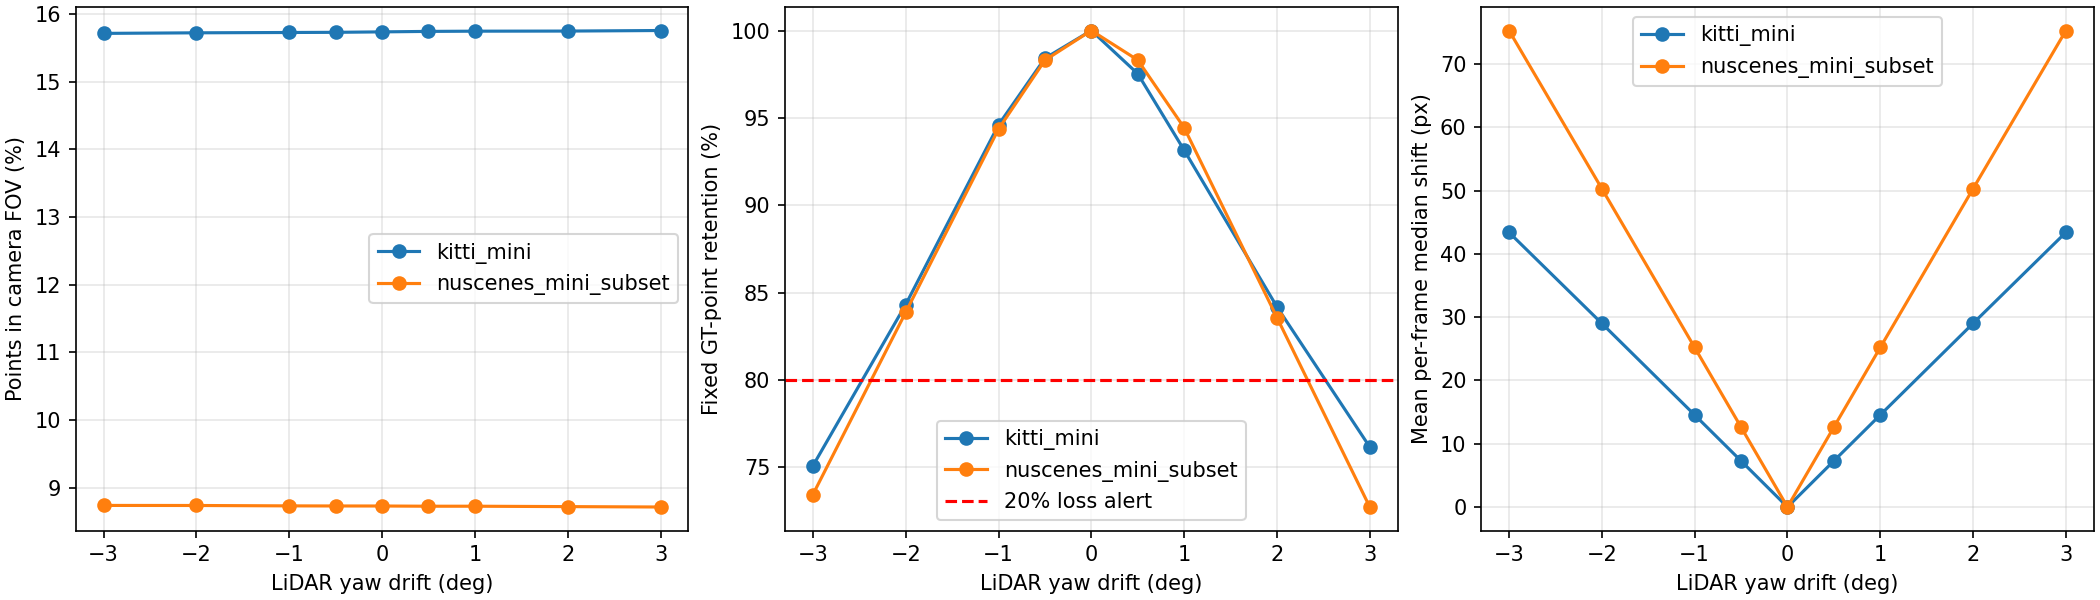

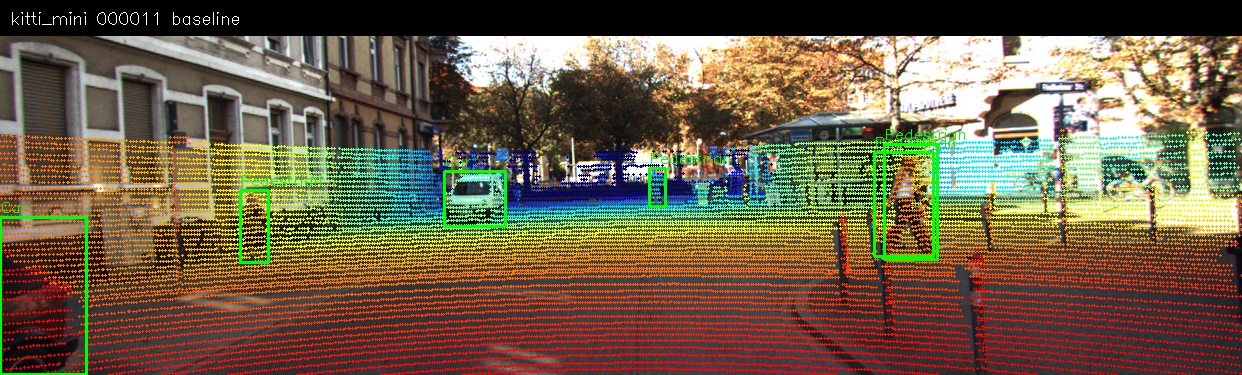

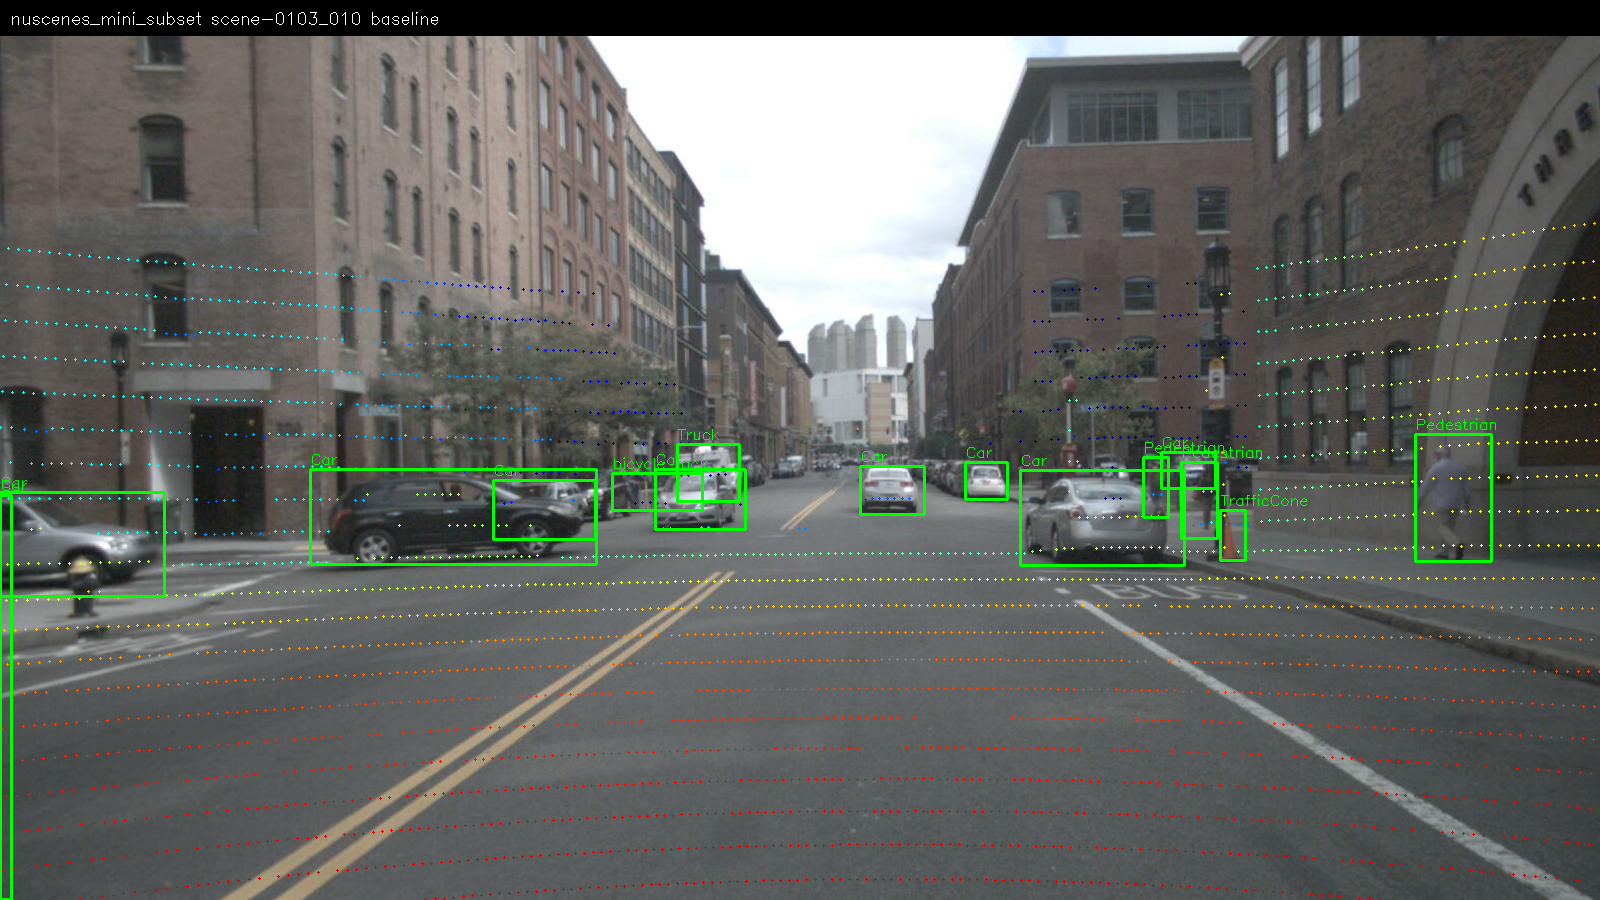

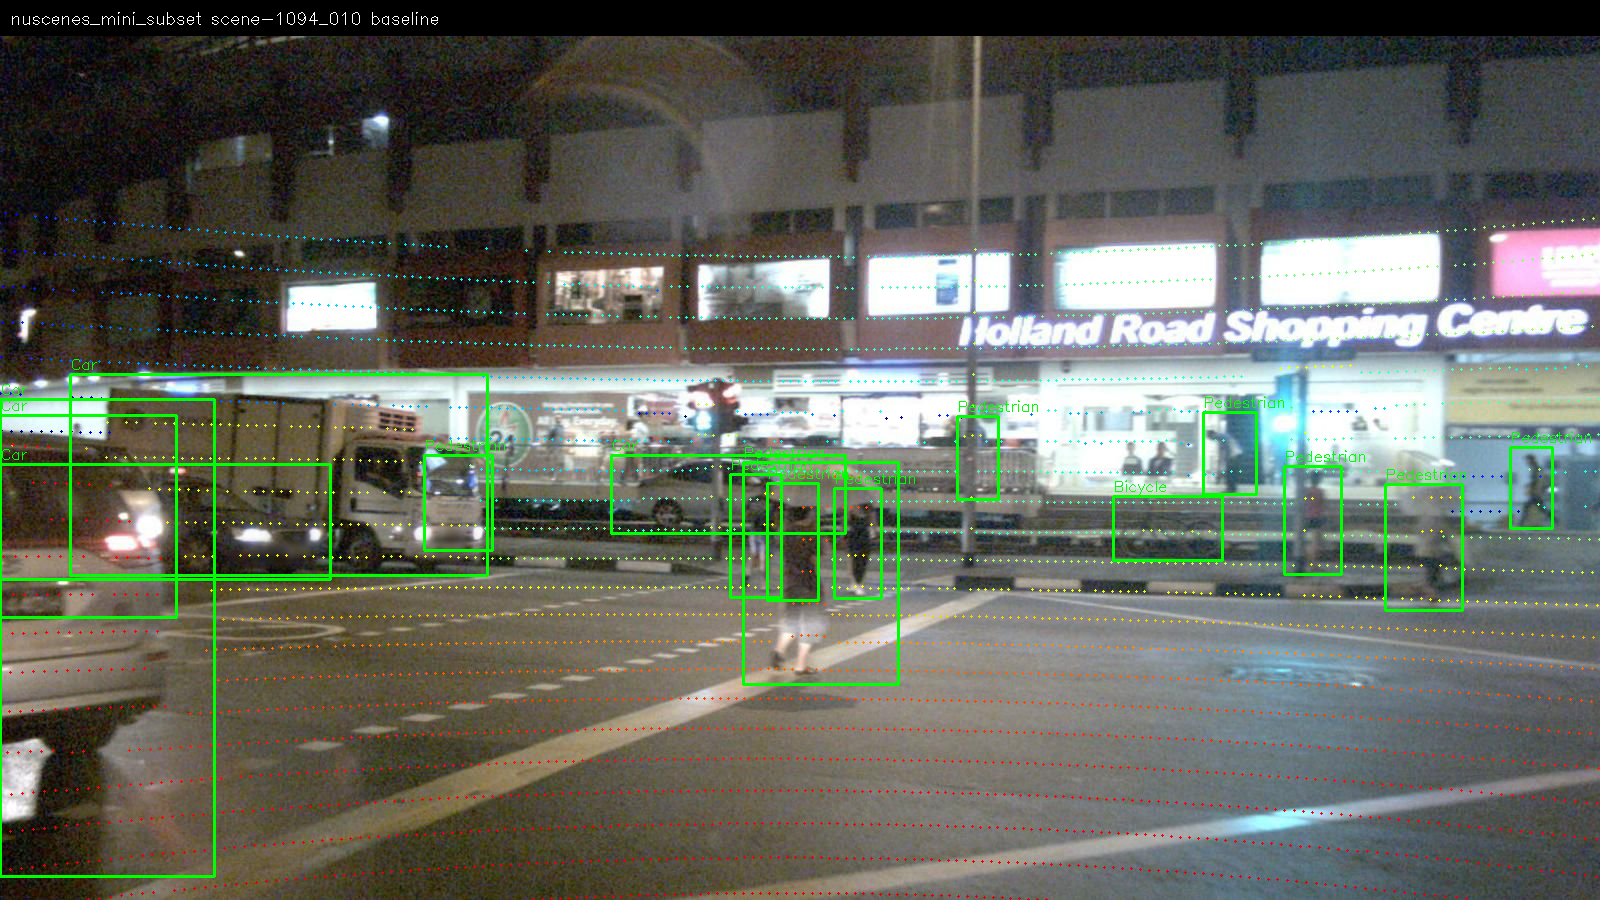

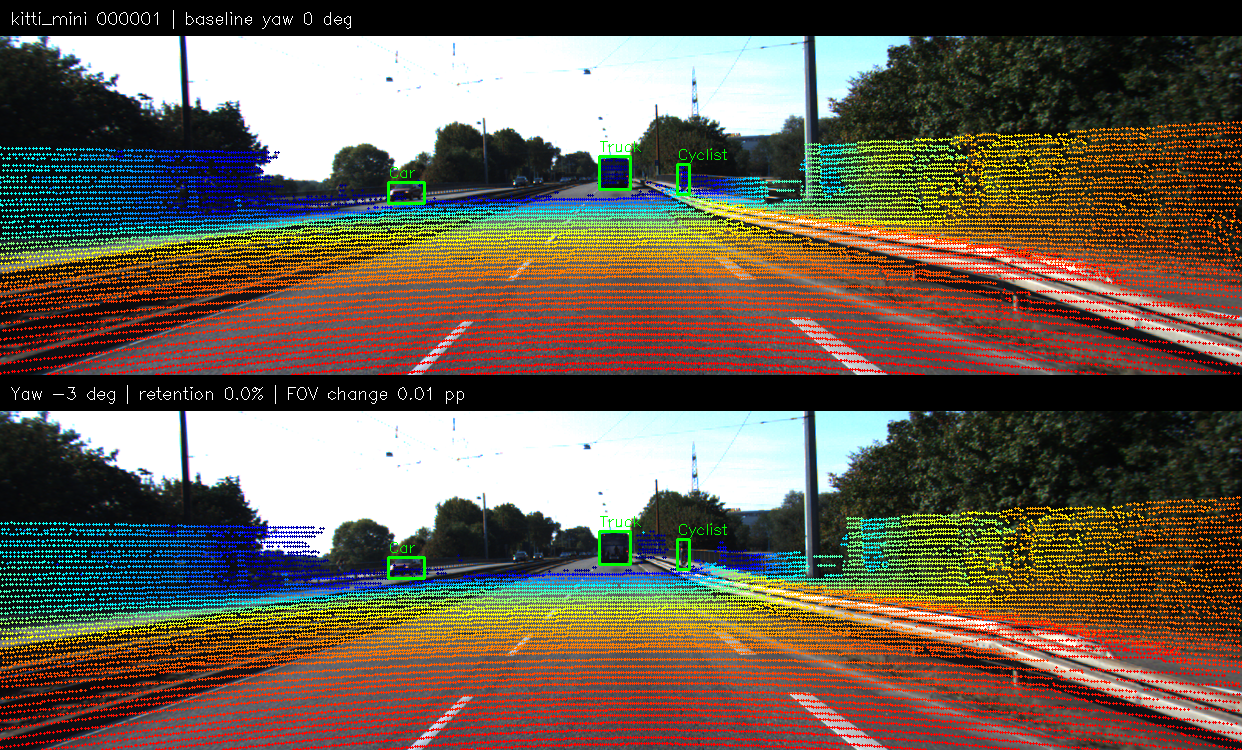

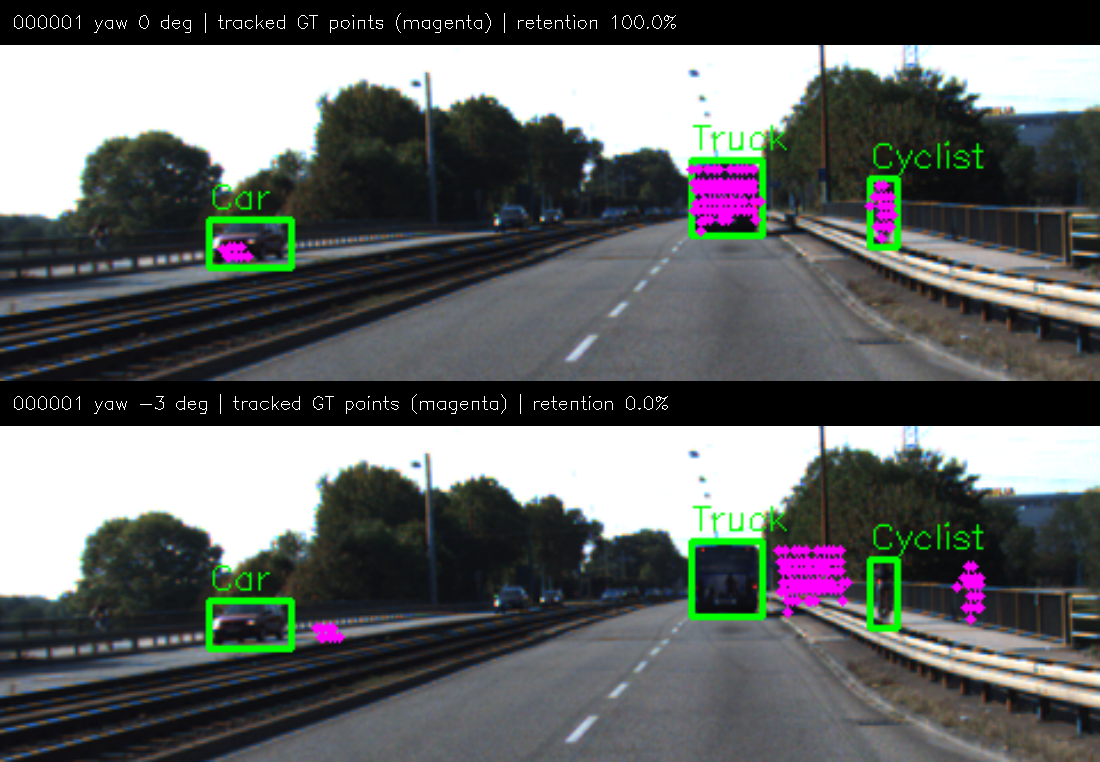

# Báo cáo Day 6: Độ nhạy calibration LiDAR–camera với yaw drift

- **Họ tên:** Nguyễn Văn Ước
- **MSSV:** 2A202602445
- **Lớp:** VinUni AI20K — Track 4
- **Link repo:** https://github.com/nvuoc/K4-Track4-Day06-3D-From-Point-Clouds
- **Tên repo khi nộp theo đề:** NguyenVanUoc-2A202602445-Track4-Day21 (remote hiện tại chưa có tên này).
- **Topic:** A — LiDAR-camera projection QA (mức Good)
- **Dataset:** data/kitti_mini, data/nuscenes_mini_subset; synthetic dùng kiểm chứng hình học.
- **Các frame đã dùng:** kitti_mini: 000001, 000004, 000007, 000008, 000009, 000010, 000011, 000012, 000015, 000016, 000019, 000021, 000023, 000025, 000031, 000032, 000043, 000048, 000049, 000061; nuscenes_mini_subset: scene-0103_000, scene-0103_001, scene-0103_002, scene-0103_003, scene-0103_004, scene-0103_005, scene-0103_006, scene-0103_007, scene-0103_008, scene-0103_009, scene-0103_010, scene-0103_011, scene-0103_012, scene-0103_013, scene-0103_014, scene-0103_015, scene-0103_016, scene-0103_017, scene-0103_018, scene-0103_019, scene-0103_020, scene-0103_021, scene-0103_022, scene-0103_023, scene-0103_024, scene-0103_025, scene-0103_026, scene-0103_027, scene-0103_028, scene-0103_029, scene-0103_030, scene-0103_031, scene-0103_032, scene-0103_033, scene-0103_034, scene-0103_035, scene-0103_036, scene-0103_037, scene-0103_038, scene-0103_039, scene-1094_000, scene-1094_001, scene-1094_002, scene-1094_003, scene-1094_004, scene-1094_005, scene-1094_006, scene-1094_007, scene-1094_008, scene-1094_009, scene-1094_010, scene-1094_011, scene-1094_012, scene-1094_013, scene-1094_014, scene-1094_015, scene-1094_016, scene-1094_017, scene-1094_018, scene-1094_019, scene-1094_020, scene-1094_021, scene-1094_022, scene-1094_023, scene-1094_024, scene-1094_025, scene-1094_026, scene-1094_027, scene-1094_028, scene-1094_029, scene-1094_030, scene-1094_031, scene-1094_032, scene-1094_033, scene-1094_034, scene-1094_035, scene-1094_036, scene-1094_037, scene-1094_038, scene-1094_039. Synthetic kiểm thử: 000000.

## 1. Claim

Trên 20 frame KITTI và 80 frame nuScenes, yaw ±3° làm mất hơn 20% tập điểm tham chiếu thuộc vật thể. Retention cao nhất ở bốn cấu hình này là 76.16%; claim được ủng hộ bởi số liệu.
Giữ nguyên ảnh, point cloud, label và bù ego-motion; chỉ đổi yaw quanh z-up của LiDAR bằng Tr @ D.
Cấu hình có seed 2445; không có phép ngẫu nhiên nên số liệu hình học tái lập hoàn toàn.

## 2. Evidence

| Dataset | Yaw (°) | Trong FOV (%) | GT đúng box riêng (%) | Retention (%) | Dịch pixel trung bình* |
|---|---:|---:|---:|---:|---:|
| kitti_mini | -3 | 15.72 | 74.93 | 75.08 | 43.39 |
| kitti_mini | -2 | 15.73 | 84.22 | 84.31 | 29.01 |
| kitti_mini | -1 | 15.73 | 94.52 | 94.60 | 14.54 |
| kitti_mini | -0.5 | 15.73 | 98.28 | 98.41 | 7.28 |
| kitti_mini | 0 | 15.74 | 99.56 | 100.00 | 0.00 |
| kitti_mini | 0.5 | 15.75 | 97.20 | 97.53 | 7.28 |
| kitti_mini | 1 | 15.75 | 92.85 | 93.15 | 14.55 |
| kitti_mini | 2 | 15.75 | 83.92 | 84.18 | 29.01 |
| kitti_mini | 3 | 15.76 | 75.92 | 76.16 | 43.40 |
| nuscenes_mini_subset | -3 | 8.74 | 73.41 | 73.44 | 75.28 |
| nuscenes_mini_subset | -2 | 8.73 | 83.83 | 83.87 | 50.30 |
| nuscenes_mini_subset | -1 | 8.73 | 94.32 | 94.36 | 25.21 |
| nuscenes_mini_subset | -0.5 | 8.73 | 98.26 | 98.30 | 12.62 |
| nuscenes_mini_subset | 0 | 8.73 | 99.95 | 100.00 | 0.00 |
| nuscenes_mini_subset | 0.5 | 8.72 | 98.30 | 98.31 | 12.62 |
| nuscenes_mini_subset | 1 | 8.72 | 94.43 | 94.44 | 25.21 |
| nuscenes_mini_subset | 2 | 8.72 | 83.57 | 83.57 | 50.29 |
| nuscenes_mini_subset | 3 | 8.71 | 72.73 | 72.72 | 75.27 |

*Dịch pixel: trung bình median từng frame trên điểm còn trong FOV ở cả baseline và drift.
GT đúng box riêng: điểm trong 3D GT và FOV baseline, sau perturb còn trong 2D box của cùng object; điểm ra khỏi ảnh tính là sai.
Retention: cố định các điểm GT khớp 2D box ở baseline, tối thiểu 5 điểm/object, rồi đo phần còn khớp. Baseline 100% là do định nghĩa, không chứng minh calibration tuyệt đối đúng.
Tổng hợp theo số điểm, không lấy trung bình % từng object; điểm thuộc nhiều box tính theo từng membership. FOV dùng mẫu số là mọi điểm XYZ hữu hạn.

![benchmark](../results/figures/yaw_benchmark.png)
![KITTI baseline](../results/figures/demo_000011.png)
![nuScenes ban ngày](../results/figures/demo_scene-0103_010.png)
![nuScenes ban đêm](../results/figures/demo_scene-1094_010.png)

Ba khoảng cách KITTI 000011: [0–15 m](../results/figures/demo_depth_0_15m.png), [15–30 m](../results/figures/demo_depth_15_30m.png), [30–80 m](../results/figures/demo_depth_30_80m.png).
Nguồn ảnh: KITTI Vision Benchmark Suite; nuScenes (Motional), dữ liệu sẵn trong repo.
CSV đầy đủ: yaw_perturb_sweep.csv (900 cấu hình frame/yaw), yaw_summary.csv, object_retention.csv. Frame, điểm lỗi và time gap ở frame_manifest.csv.
Hai dataset khác số beam (64/32), FOV, ảnh và phân bố object; nuScenes có chênh timestamp và bù ego-motion. Đây là các nguyên nhân có thể ảnh hưởng khác biệt; thí nghiệm chưa tách được đóng góp của từng yếu tố.

## 3. Failure case

![baseline trên, drift dưới; điểm tham chiếu màu tím](../results/figures/fail_02_gt_points_zoom.png)
Ảnh toàn cảnh: [baseline/drift](../results/figures/fail_01_fov_misses_drift.png).

kitti_mini frame 000001, yaw -3°: retention chỉ 0.00% trên 97 điểm tham chiếu, trong khi FOV chỉ đổi +0.006 điểm phần trăm.
Lỗi **Geometry**: yaw extrinsic sai làm điểm lệch khỏi object. Lỗi **Metric**: cảnh báo chỉ dựa trên |ΔFOV| ≥ 1 điểm phần trăm sẽ bỏ sót case này, vì điểm lệch khỏi xe/người nhưng vẫn trong ảnh.
Loss ≥20% có thể cảnh báo case này, nhưng cần GT và baseline đúng; chưa phải bộ phát hiện drift tự động lúc vận hành.
Hạn chế: ngưỡng ≥5 điểm bỏ qua object quá thưa; box 2D có nền/che khuất, và box 2D nuScenes suy từ 3D nên không phải GT camera độc lập. Bù ego-motion chưa bù chuyển động object hay deskew toàn sweep.

## 4. Khuyến nghị nếu triển khai thật

Với ADAS, kiểm tra calibration sau va chạm/sửa gá sensor bằng object nhỏ như người/cyclist, kết hợp edge alignment và timestamp.
Ghi log invalid ratio, FOV ratio, số điểm/object, alignment score theo range/class, time gap và phiên bản calibration.
Projection dùng CPU, tránh chi phí GPU; giảm tần suất QA/số điểm giảm tải nhưng có thể bỏ qua object nhỏ và drift ngắn.
Ngưỡng 20% loss và 1 điểm phần trăm FOV là minh hoạ: phải hiệu chỉnh trên dữ liệu sạch, drift thật và false alarm trước triển khai. Không suy ra độ chính xác detector từ metric này.

## 5. Cách chạy lại

Từ gốc repo, Python ≥3.10, CPU là đủ:

    python -m pip install -r requirements.txt
    python tools/verify_data.py --data-root data/kitti_mini
    python tools/verify_data.py --data-root data/nuscenes_mini_subset
    python -m unittest src.test_geometry -v
    python -m starter.data_health --data-root data/synthetic
    python -m src.calibration_qa
    python -m src.failure_detail
    python -m src.make_report
    python tools/check_submission.py

Môi trường Windows đã chạy trong phiên này: .venv-cpu/Scripts/python.exe (Python 3.14). Dùng đường dẫn này thay python nếu PATH trỏ tới Python MSYS2; phiên bản thư viện ghi ở src/requirements-tested.txt.
Tham số: python -m src.calibration_qa --help. Colab: src/NguyenVanUoc_2A202602445_Colab.ipynb, chọn CPU, Run all.
Notebook lấy dữ liệu đề, ghi các file triển khai đi kèm, chạy test/benchmark/báo cáo; không cần đã push code mới. Chỉ kiểm tra notebook bằng môi trường local tương đương, chưa chạy dịch vụ Colab.
Tái lập: chạy benchmark hai lần và so SHA-256 các CSV hình học; log ở results/validation.txt.
Trước nộp: đổi tên fork đúng mẫu, push source/results/report, nộp URL và commit hash lên LMS. Các bước tài khoản/LMS chưa thực hiện trong phiên này.

## 6. Khai báo sử dụng AI

| Công cụ | Dùng cho việc gì | Kiểm chứng |
|---|---|---|
| OpenAI Codex | Đọc đề, chọn topic, viết projection, benchmark, tests, notebook, báo cáo và tạo artifacts từ code chạy thật | Agent chạy verify_data, kiểm thử điểm (10,0,0), NaN/Inf/FOV, box xoay; benchmark hai lần, đối chiếu CSV và mở ảnh. Học viên cần tự chạy notebook và đọc/giải thích code trước nộp. |

Không khai báo học viên đã tự kiểm chứng trong phiên này. Không dùng detector/checkpoint, không bịa số liệu; bảng sinh từ CSV.


In [6]:
import pandas as pd
from IPython.display import display, Image, Markdown
display(pd.read_csv("results/yaw_summary.csv"))
for image_path in ["results/figures/yaw_benchmark.png", "results/figures/demo_000011.png", "results/figures/demo_scene-0103_010.png", "results/figures/demo_scene-1094_010.png", "results/figures/fail_01_fov_misses_drift.png", "results/figures/fail_02_gt_points_zoom.png"]:
    display(Image(filename=image_path, width=1000))
display(Markdown(Path("report/REPORT.md").read_text(encoding="utf-8")))

## Tải bài về
ZIP chỉ dùng chuyển kết quả về máy, **không commit ZIP** vào repo. Giải nén các thư mục src/results/report và starter/projection.py vào bản fork. Đổi tên fork thành **NguyenVanUoc-2A202602445-Track4-Day21**, sửa Link repo trong REPORT tương ứng rồi commit/push; lấy commit hash nộp LMS. Notebook không tự push hay nộp bài.

In [7]:
import zipfile
from google.colab import files
archive = Path("/content/NguyenVanUoc_2A202602445_submission.zip")
with zipfile.ZipFile(archive, "w", zipfile.ZIP_DEFLATED) as z:
    for directory in ["src", "results", "report"]:
        for p in Path(directory).rglob("*"):
            if p.is_file() and "__pycache__" not in p.parts:
                z.write(p, str(p))
    z.write("starter/projection.py")
files.download(str(archive))

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>